# Pronóstico multivariado y multistep de demanda

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, Model

import matplotlib.pyplot as plt

### Dependencia para baselines estadísticos

Estos modelos pertenecen a **StatsForecast (Nixtla)**, no a `statsmodels`.
La instalación se ejecuta solamente si el paquete no está disponible.

In [2]:
try:
    from statsforecast import StatsForecast
    from statsforecast.models import HoltWinters, SeasonalNaive, ARIMA
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsforecast==2.1.1"])
    from statsforecast import StatsForecast
    from statsforecast.models import HoltWinters, SeasonalNaive, ARIMA


/home/gibran/anaconda3/envs/tf219/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cargar dataset

[Data](https://www.kaggle.com/datasets/utathya/future-volume-prediction)

In [3]:
root_path = "../data/VolumeForecasting/train_OwBvO8W/"

In [4]:
vol = pd.read_csv(root_path + "historical_volume.csv")
psp = pd.read_csv(root_path + "price_sales_promotion.csv")
wth = pd.read_csv(root_path + "weather.csv")
evt = pd.read_csv(root_path + "event_calendar.csv")
ind_soda = pd.read_csv(root_path + "industry_soda_sales.csv")
ind_vol = pd.read_csv(root_path+ "industry_volume.csv")
demo = pd.read_csv(root_path +"demographics.csv")

In [5]:
vol.head()

,Agency,SKU,YearMonth,Volume
0,Agency_22,SKU_01,201301,52.2720
1,Agency_22,SKU_02,201301,110.7000
2,Agency_58,SKU_23,201301,0.0000
3,Agency_48,SKU_07,201301,28.3200
4,Agency_22,SKU_05,201301,238.5387


In [6]:
psp.head()

,Agency,SKU,YearMonth,Price,Sales,Promotions
0,Agency_01,SKU_01,201301,1141.500000,1033.432731,108.067269
1,Agency_01,SKU_01,201302,1141.500000,1065.417195,76.082805
2,Agency_01,SKU_01,201303,1179.345820,1101.133633,78.212187
3,Agency_01,SKU_01,201304,1226.687500,1138.283357,88.404143
4,Agency_01,SKU_01,201305,1230.331104,1148.969634,81.361470


In [7]:
wth.head()

,YearMonth,Agency,Avg_Max_Temp
0,201301,Agency_01,17.072
1,201302,Agency_01,19.984
2,201303,Agency_01,24.600
3,201304,Agency_01,27.532
4,201305,Agency_01,29.396


In [8]:
evt.head()

,YearMonth,Easter Day,Good Friday,New Year,Christmas,Labor Day,Independence Day,Revolution Day Memorial,Regional Games,FIFA U-17 World Cup,Football Gold Cup,Beer Capital,Music Fest
0,201301,0,0,1,0,0,0,0,0,0,0,0,0
1,201302,0,0,0,0,0,0,0,0,0,0,0,0
2,201303,1,1,0,0,0,0,0,0,0,0,0,1
3,201304,0,0,0,0,0,0,0,0,0,0,0,0
4,201305,0,0,0,0,1,0,0,0,0,0,0,0


In [9]:
ind_soda.head()

,YearMonth,Soda_Volume
0,201301,718394219
1,201302,753938444
2,201303,892192092
3,201304,838099501
4,201305,864420003


In [10]:
demo.head()

,Agency,Avg_Population_2017,Avg_Yearly_Household_Income_2017
0,Agency_05,3044268,182944
1,Agency_02,3137874,240809
2,Agency_55,2025793,238553
3,Agency_53,1729177,111048
4,Agency_50,2057678,144594


In [11]:
def ensure_month(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["YearMonth"], format="%Y%m") 
    df.drop(["YearMonth"], inplace=True, axis=1)
    return df

In [12]:
vol = ensure_month(vol)
psp = ensure_month(psp)
wth = ensure_month(wth)
evt = ensure_month(evt)
ind_soda = ensure_month(ind_soda)
ind_vol = ensure_month(ind_vol)

In [13]:
vol.head()

,Agency,SKU,Volume,date
0,Agency_22,SKU_01,52.2720,2013-01-01
1,Agency_22,SKU_02,110.7000,2013-01-01
2,Agency_58,SKU_23,0.0000,2013-01-01
3,Agency_48,SKU_07,28.3200,2013-01-01
4,Agency_22,SKU_05,238.5387,2013-01-01


In [14]:
def rename_keys(df):
    df = df.copy()
    ren = {}
    for c in df.columns:
        if c.lower() == "agency": ren[c] = "agency"
        if c.lower() == "sku": ren[c] = "sku"
    return df.rename(columns=ren)

vol, psp, wth, evt, ind_soda, ind_vol, demo = map(rename_keys, [vol, psp, wth, evt, ind_soda, ind_vol, demo])

In [15]:
vol.head()

,agency,sku,Volume,date
0,Agency_22,SKU_01,52.2720,2013-01-01
1,Agency_22,SKU_02,110.7000,2013-01-01
2,Agency_58,SKU_23,0.0000,2013-01-01
3,Agency_48,SKU_07,28.3200,2013-01-01
4,Agency_22,SKU_05,238.5387,2013-01-01


In [16]:
df = vol.merge(psp, on=["agency","sku","date"], how="left")
df = df.merge(wth, on=["agency","date"], how="left")
df = df.merge(evt, on=["date"], how="left")
df = df.merge(ind_soda, on=["date"], how="left")
df = df.merge(ind_vol, on=["date"], how="left")
df = df.merge(demo, on=["agency"], how="left")

In [17]:
df = df.sort_values(["agency","sku","date"]).reset_index(drop=True)

In [18]:
print(df.columns)

Index(['agency', 'sku', 'Volume', 'date', 'Price', 'Sales', 'Promotions',
       'Avg_Max_Temp', 'Easter Day', 'Good Friday', 'New Year', 'Christmas',
       'Labor Day', 'Independence Day', 'Revolution Day Memorial',
       'Regional Games ', 'FIFA U-17 World Cup', 'Football Gold Cup',
       'Beer Capital', 'Music Fest', 'Soda_Volume', 'Industry_Volume',
       'Avg_Population_2017', 'Avg_Yearly_Household_Income_2017'],
      dtype='object')


In [19]:
df.head()

,agency,sku,Volume,date,Price,Sales,Promotions,Avg_Max_Temp,Easter Day,Good Friday,...,Revolution Day Memorial,Regional Games,FIFA U-17 World Cup,Football Gold Cup,Beer Capital,Music Fest,Soda_Volume,Industry_Volume,Avg_Population_2017,Avg_Yearly_Household_Income_2017
0,Agency_01,SKU_01,80.676,2013-01-01,1141.500000,1033.432731,108.067269,17.072,0,0,...,0,0,0,0,0,0,718394219,492612703,153733,120207
1,Agency_01,SKU_01,98.064,2013-02-01,1141.500000,1065.417195,76.082805,19.984,0,0,...,0,0,0,0,0,0,753938444,431937346,153733,120207
2,Agency_01,SKU_01,133.704,2013-03-01,1179.345820,1101.133633,78.212187,24.600,1,1,...,0,0,0,0,0,1,892192092,509281531,153733,120207
3,Agency_01,SKU_01,147.312,2013-04-01,1226.687500,1138.283357,88.404143,27.532,0,0,...,0,0,0,0,0,0,838099501,532390389,153733,120207
4,Agency_01,SKU_01,175.608,2013-05-01,1230.331104,1148.969634,81.361470,29.396,0,0,...,0,0,0,0,0,0,864420003,551755254,153733,120207


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   agency                            21000 non-null  object        
 1   sku                               21000 non-null  object        
 2   Volume                            21000 non-null  float64       
 3   date                              21000 non-null  datetime64[ns]
 4   Price                             21000 non-null  float64       
 5   Sales                             21000 non-null  float64       
 6   Promotions                        21000 non-null  float64       
 7   Avg_Max_Temp                      21000 non-null  float64       
 8   Easter Day                        21000 non-null  int64         
 9   Good Friday                       21000 non-null  int64         
 10  New Year                          21000 non-nu

# Preprocesado e ingeniería de variables

In [21]:
TARGET_COL = "Volume"

# Calendario: enero y diciembre deben quedar próximos en la representación.
df["month_sin"] = np.sin(2 * np.pi * df["date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["date"].dt.month / 12)
df["year"] = df["date"].dt.year

# Lags por serie.
g = df.groupby(["agency", "sku"], sort=False)
for lag in [1, 3, 6, 12]:
    df[f"{TARGET_COL}_lag_{lag}"] = g[TARGET_COL].shift(lag)

# IMPORTANTE: rolling dentro de cada serie; no cruza agencia/SKU.
df[f"{TARGET_COL}_roll_3"] = g[TARGET_COL].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
df[f"{TARGET_COL}_roll_6"] = g[TARGET_COL].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

# Objetivo sin escalar y copia histórica segura. La ventana X termina en t-1,
# por lo que volume_log nunca contiene el objetivo futuro t:t+HORIZON.
df["y"] = np.log1p(df[TARGET_COL].astype(float))
df["volume_log"] = df["y"]

df = df.dropna().reset_index(drop=True)


In [22]:
df

,agency,sku,Volume,date,Price,Sales,Promotions,Avg_Max_Temp,Easter Day,Good Friday,...,month_cos,year,Volume_lag_1,Volume_lag_3,Volume_lag_6,Volume_lag_12,Volume_roll_3,Volume_roll_6,y,volume_log
0,Agency_01,SKU_01,100.548,2014-01-01,1235.187500,995.006244,240.181256,19.092308,0,0,...,8.660254e-01,2014,104.544,149.364,149.796,80.676,116.424,134.658,4.620532,4.620532
1,Agency_01,SKU_01,123.552,2014-02-01,1235.187500,1111.858392,123.329108,23.319231,0,0,...,5.000000e-01,2014,100.548,95.364,161.136,98.064,100.152,126.450,4.824723,4.824723
2,Agency_01,SKU_01,125.172,2014-03-01,1235.187500,1108.242181,126.945319,23.150000,0,0,...,6.123234e-17,2014,123.552,104.544,147.744,133.704,109.548,120.186,4.837646,4.837646
3,Agency_01,SKU_01,70.524,2014-04-01,1235.187500,1109.019047,126.168453,26.569231,1,1,...,-5.000000e-01,2014,125.172,100.548,149.364,147.312,116.424,116.424,4.270033,4.270033
4,Agency_01,SKU_01,21.924,2014-05-01,1264.272500,1257.190000,7.082500,29.430769,0,0,...,-8.660254e-01,2014,70.524,123.552,95.364,175.608,106.416,103.284,3.132184,3.132184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,Agency_60,SKU_23,1.980,2017-08-01,4254.975000,4254.975000,0.000000,28.417411,0,0,...,-5.000000e-01,2017,2.160,0.000,2.520,2.340,1.560,1.695,1.091923,1.091923
16796,Agency_60,SKU_23,1.260,2017-09-01,4256.796429,4256.796429,0.000000,27.591111,0,0,...,-1.836970e-16,2017,1.980,2.520,1.710,3.600,2.220,1.605,0.815365,0.815365
16797,Agency_60,SKU_23,0.990,2017-10-01,4262.625000,4262.625000,0.000000,27.558824,0,0,...,5.000000e-01,2017,1.260,2.160,1.260,2.070,1.800,1.530,0.688135,0.688135
16798,Agency_60,SKU_23,0.090,2017-11-01,4262.625000,4262.625000,0.000000,27.674091,0,0,...,8.660254e-01,2017,0.990,1.980,0.000,0.360,1.410,1.485,0.086178,0.086178


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16800 entries, 0 to 16799
Data columns (total 35 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   agency                            16800 non-null  object        
 1   sku                               16800 non-null  object        
 2   Volume                            16800 non-null  float64       
 3   date                              16800 non-null  datetime64[ns]
 4   Price                             16800 non-null  float64       
 5   Sales                             16800 non-null  float64       
 6   Promotions                        16800 non-null  float64       
 7   Avg_Max_Temp                      16800 non-null  float64       
 8   Easter Day                        16800 non-null  int64         
 9   Good Friday                       16800 non-null  int64         
 10  New Year                          16800 non-nu

In [24]:
# Variables numéricas de entrada. "y" es el objetivo sin escalar;
# "volume_log" es su copia histórica y sí pertenece a X.
exclude = {"date", "agency", "sku", TARGET_COL, "y"}
num_cols = [c for c in df.columns if c not in exclude and df[c].dtype != "object"]


In [25]:
num_cols

['Price',
 'Sales',
 'Promotions',
 'Avg_Max_Temp',
 'Easter Day',
 'Good Friday',
 'New Year',
 'Christmas',
 'Labor Day',
 'Independence Day',
 'Revolution Day Memorial',
 'Regional Games ',
 'FIFA U-17 World Cup',
 'Football Gold Cup',
 'Beer Capital',
 'Music Fest',
 'Soda_Volume',
 'Industry_Volume',
 'Avg_Population_2017',
 'Avg_Yearly_Household_Income_2017',
 'month_sin',
 'month_cos',
 'year',
 'Volume_lag_1',
 'Volume_lag_3',
 'Volume_lag_6',
 'Volume_lag_12',
 'Volume_roll_3',
 'Volume_roll_6',
 'volume_log']

In [26]:
len(num_cols)

30

In [27]:
# ids
agency_ids = {a:i for i,a in enumerate(df["agency"].unique())}
sku_ids = {s:i for i,s in enumerate(df["sku"].unique())}
df["agency_id"] = df["agency"].map(agency_ids)
df["sku_id"] = df["sku"].map(sku_ids)

In [28]:
# scale numerics
#scaler = StandardScaler()
#df[num_cols] = scaler.fit_transform(df[num_cols].values)

In [29]:
# Cortes cronológicos de origen fijo:
# - train: los 3 objetivos terminan antes de julio de 2017
# - validación: pronóstico julio-septiembre
# - test final: pronóstico octubre-diciembre
VAL_ORIGIN = pd.Timestamp("2017-07-01")
TEST_ORIGIN = pd.Timestamp("2017-10-01")

# Evita FutureWarning al asignar resultados float sobre columnas enteras.
df[num_cols] = df[num_cols].astype("float64")

# El scaler aprende exclusivamente de filas anteriores a la validación.
scaler = StandardScaler()
scale_train_rows = df["date"] < VAL_ORIGIN
scaler.fit(df.loc[scale_train_rows, num_cols])
df.loc[:, num_cols] = scaler.transform(df[num_cols])


In [30]:
df

,agency,sku,Volume,date,Price,Sales,Promotions,Avg_Max_Temp,Easter Day,Good Friday,...,Volume_lag_1,Volume_lag_3,Volume_lag_6,Volume_lag_12,Volume_roll_3,Volume_roll_6,y,volume_log,agency_id,sku_id
0,Agency_01,SKU_01,100.548,2014-01-01,-0.345801,-0.492425,0.179449,-2.402788,-0.324443,-0.324443,...,-0.509786,-0.494511,-0.495681,-0.526052,-0.511503,-0.507231,4.620532,-0.058543,0,0
1,Agency_01,SKU_01,123.552,2014-02-01,-0.345801,-0.291608,-0.236224,-1.317223,-0.324443,-0.324443,...,-0.511255,-0.514575,-0.491478,-0.519507,-0.517584,-0.510319,4.824723,0.010256,0,0
2,Agency_01,SKU_01,125.172,2014-03-01,-0.345801,-0.297823,-0.223360,-1.360685,-0.324443,-0.324443,...,-0.502801,-0.511164,-0.496442,-0.506092,-0.514073,-0.512676,4.837646,0.014610,0,0
3,Agency_01,SKU_01,70.524,2014-04-01,-0.345801,-0.296487,-0.226124,-0.482552,3.082207,3.082207,...,-0.502206,-0.512649,-0.495841,-0.500969,-0.511503,-0.514091,4.270033,-0.176639,0,0
4,Agency_01,SKU_01,21.924,2014-05-01,-0.303161,-0.041847,-0.649743,0.252353,-0.324443,-0.324443,...,-0.522289,-0.504102,-0.515858,-0.490318,-0.515243,-0.519035,3.132184,-0.560021,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16795,Agency_60,SKU_23,1.980,2017-08-01,4.081384,5.110031,-0.674937,-0.007899,-0.324443,-0.324443,...,-0.547412,-0.550009,-0.550274,-0.555539,-0.554427,-0.557254,1.091923,-1.247458,57,12
16796,Agency_60,SKU_23,1.260,2017-09-01,4.084054,5.113161,-0.674937,-0.220111,-0.324443,-0.324443,...,-0.547478,-0.549073,-0.550574,-0.555065,-0.554180,-0.557288,0.815365,-1.340640,57,12
16797,Agency_60,SKU_23,0.990,2017-10-01,4.092599,5.123178,-0.674937,-0.228403,-0.324443,-0.324443,...,-0.547743,-0.549207,-0.550741,-0.555641,-0.554337,-0.557316,0.688135,-1.383509,57,12
16798,Agency_60,SKU_23,0.090,2017-11-01,4.092599,5.123178,-0.674937,-0.198800,-0.324443,-0.324443,...,-0.547842,-0.549274,-0.551208,-0.556284,-0.554483,-0.557333,0.086178,-1.586329,57,12


In [31]:
LOOKBACK = 24
HORIZON = 3

def make_windows_with_dates(frame):
    X_seq, X_ag, X_sku, Y = [], [], [], []
    origin_month, end_month = [], []

    for (a, s), sub in frame.groupby(["agency_id", "sku_id"], sort=False):
        sub = sub.sort_values("date")
        x_num = sub[num_cols].to_numpy(dtype="float32")
        y = sub["y"].to_numpy(dtype="float32")
        months = sub["date"].to_numpy()

        for t in range(LOOKBACK, len(sub) - HORIZON + 1):
            X_seq.append(x_num[t-LOOKBACK:t])
            X_ag.append(a)
            X_sku.append(s)
            Y.append(y[t:t+HORIZON])
            origin_month.append(months[t])
            end_month.append(months[t + HORIZON - 1])

    return (
        np.asarray(X_seq, dtype="float32"),
        np.asarray(X_ag, dtype="int32"),
        np.asarray(X_sku, dtype="int32"),
        np.asarray(Y, dtype="float32").reshape(-1, HORIZON),
        pd.to_datetime(origin_month),
        pd.to_datetime(end_month),
    )


In [32]:
X_seq, X_ag, X_sku, Y, origin_month, end_month = make_windows_with_dates(df)
print(X_seq.shape, X_ag.shape, X_sku.shape, Y.shape)


(7700, 24, 30) (7700,) (7700,) (7700, 3)


In [33]:
X_seq.shape

(7700, 24, 30)

In [34]:
X_ag

array([ 0,  0,  0, ..., 57, 57, 57], dtype=int32)

In [35]:
X_sku

array([ 0,  0,  0, ..., 12, 12, 12], dtype=int32)

In [36]:

train_idx = end_month < VAL_ORIGIN
val_idx = origin_month == VAL_ORIGIN
test_idx = origin_month == TEST_ORIGIN

def select_inputs(mask):
    return [X_seq[mask], X_ag[mask], X_sku[mask]]

Xtr, Ytr = select_inputs(train_idx), Y[train_idx]
Xva, Yva = select_inputs(val_idx), Y[val_idx]
Xte, Yte = select_inputs(test_idx), Y[test_idx]

print("Train windows:", len(Ytr))
print("Validation windows (Jul-Sep):", len(Yva))
print("Test windows (Oct-Dec):", len(Yte))

assert end_month[train_idx].max() < VAL_ORIGIN
assert np.all(origin_month[val_idx] == VAL_ORIGIN)
assert np.all(origin_month[test_idx] == TEST_ORIGIN)


Train windows: 5600
Validation windows (Jul-Sep): 350
Test windows (Oct-Dec): 350


# Modelo: LSTM + embeddings + Dense

In [37]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

n_agency = len(agency_ids)
n_sku = len(sku_ids)
n_feat = X_seq.shape[-1]

emb_dim = 16
lstm_units = 64

In [38]:
n_sku

25

In [39]:
n_agency

58

In [40]:
n_feat

30

In [41]:
# texto
# tokenizado --> {"carro": 1, "coche": 2, ...}
# embedding ---> id ---> vector
# vec1 = ag_emb(id1), vec2 = ag_emb(id2)
# cosine_distance = < vec1, vec2> / || ||


In [42]:
seq_in = layers.Input(shape=(LOOKBACK, n_feat), name="seq")
ag_in = layers.Input(shape=(1,), dtype="int32", name="agency_id")
sku_in = layers.Input(shape=(1,), dtype="int32", name="sku_id")

ag_emb = layers.Flatten()(layers.Embedding(n_agency, emb_dim)(ag_in))
sku_emb = layers.Flatten()(layers.Embedding(n_sku, emb_dim)(sku_in))

x = layers.LSTM(lstm_units)(seq_in)

x = layers.Concatenate()([x, ag_emb, sku_emb])

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
out = layers.Dense(HORIZON, activation="softplus")(x)

model = Model([seq_in, ag_in, sku_in], out)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.summary()

I0000 00:00:1788483136.767351 1685416 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11597 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ agency_id           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sku_id (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 24, 30)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16)     │        928 │ agency_id[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 16)     │        400 │ sku_id[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     24,320 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,451 (150.20 KB)

 Trainable params: 38,451 (150.20 KB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento

In [43]:
BATCH = 128

train_ds = tf.data.Dataset.from_tensor_slices(((Xtr[0], Xtr[1], Xtr[2]), Ytr))
train_ds = train_ds.shuffle(len(Ytr), seed=SEED, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(((Xva[0], Xva[1], Xva[2]), Yva))
val_ds = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/60


I0000 00:00:1788483285.529505 1686406 cuda_dnn.cc:529] Loaded cuDNN version 91001


44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 17.3273 - mae: 3.4148 - val_loss: 1.5369 - val_mae: 1.0545 - learning_rate: 0.0010
Epoch 2/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 1.2331 - mae: 0.8706 - val_loss: 0.5429 - val_mae: 0.5375 - learning_rate: 0.0010
Epoch 3/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.7433 - mae: 0.6527 - val_loss: 0.4375 - val_mae: 0.4724 - learning_rate: 0.0010
Epoch 4/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.6719 - mae: 0.6185 - val_loss: 0.4151 - val_mae: 0.4616 - learning_rate: 0.0010
Epoch 5/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.5944 - mae: 0.5767 - val_loss: 0.4520 - val_mae: 0.5191 - learning_rate: 0.0010
Epoch 6/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.5640 - mae: 0.5585 - val_loss: 0.3948 - val_mae: 0.4464 - learning_rate: 0.0010
Epoch 7/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.5569 - mae: 0.5519 - val_loss: 0.4027 - val_mae: 0.4666 - learning_rate: 0.0010
Epoch 8/60
44/44 ━━━━━━

# Evaluación en validación y test

In [45]:
def predict_volume(inputs):
    pred_log = model.predict(inputs, batch_size=2048, verbose=0)
    return np.maximum(np.expm1(pred_log), 0.0)

Yva_volume = np.expm1(Yva)
Yte_volume = np.expm1(Yte)
Yhat_va = predict_volume(Xva)
Yhat_te = predict_volume(Xte)


In [74]:
Xva[0][55].shape

(24, 30)

In [75]:
Xva[1][55]

8

In [76]:
Xva[2][55]

2

In [48]:
def regression_metrics(y_true, y_pred):
    rows = []
    for h in range(y_true.shape[1]):
        yt, yp = y_true[:, h], y_pred[:, h]
        err = yp - yt
        rows.append({
            "horizon": h + 1,
            "MAE": np.mean(np.abs(err)),
            "RMSE": np.sqrt(np.mean(err ** 2)),
            "WAPE_%": 100 * np.sum(np.abs(err)) / np.maximum(np.sum(np.abs(yt)), 1e-8),
            "RMSLE": np.sqrt(np.mean((np.log1p(yp) - np.log1p(yt)) ** 2)),
            "Bias": np.mean(err),
        })
    return pd.DataFrame(rows).set_index("horizon")

print("VALIDACIÓN: julio-septiembre")
display(regression_metrics(Yva_volume, Yhat_va).round(3))
print("TEST: octubre-diciembre")
display(regression_metrics(Yte_volume, Yhat_te).round(3))


VALIDACIÓN: julio-septiembre


,MAE,RMSE,WAPE_%,RMSLE,Bias
horizon,,,,,
1,223.595001,568.823975,13.573,0.503,-77.001999
2,300.937012,722.200012,17.568,0.466,-228.500000
3,271.542999,655.401001,17.064,0.614,-174.438004


TEST: octubre-diciembre


,MAE,RMSE,WAPE_%,RMSLE,Bias
horizon,,,,,
1,274.397003,641.651001,17.701,0.558,-130.649002
2,255.735992,640.437988,19.547,0.742,101.223000
3,311.304993,717.193970,19.692,0.716,-89.343002


- MAE	¿Cuántas unidades me equivoco normalmente?
- RMSE	¿Tengo errores extremos grandes?
- WAPE	¿Qué porcentaje del volumen total representa mi error?
- RMSLE	¿Qué tan grandes son mis errores relativos/multiplicativos?
- Bias	¿Tiendo a predecir por encima o por debajo?

## Baselines

In [49]:
volume_lookup = (
    df[["agency_id", "sku_id", "date", TARGET_COL]]
    .set_index(["agency_id", "sku_id", "date"])[TARGET_COL]
)

def make_baselines(mask):
    last_rows, seasonal_rows = [], []
    for agency, sku, origin in zip(X_ag[mask], X_sku[mask], origin_month[mask]):
        last_value = volume_lookup.loc[(agency, sku, origin - pd.DateOffset(months=1))]
        last_rows.append([last_value] * HORIZON)

        forecast_months = pd.date_range(origin, periods=HORIZON, freq="MS")
        seasonal_rows.append([
            volume_lookup.loc[(agency, sku, month - pd.DateOffset(years=1))]
            for month in forecast_months
        ])

    return np.asarray(last_rows), np.asarray(seasonal_rows)

last_va, seasonal_va = make_baselines(val_idx)
last_te, seasonal_te = make_baselines(test_idx)

comparison = pd.concat({
    "LSTM": regression_metrics(Yte_volume, Yhat_te),
    "Último valor": regression_metrics(Yte_volume, last_te),
    "Estacional 12m": regression_metrics(Yte_volume, seasonal_te),
})
display(comparison.round(3))


MAE      RMSE  WAPE_%  RMSLE     Bias
               horizon                                           
LSTM           1        274.397   641.651  17.701  0.558 -130.649
               2        255.736   640.438  19.547  0.742  101.223
               3        311.305   717.194  19.692  0.716  -89.343
Último valor   1        271.692   681.996  17.527  0.513   41.179
               2        386.065  1009.513  29.508  0.830  283.007
               3        322.309   817.811  20.388  0.835   10.430
Estacional 12m 1        292.040   703.958  18.839  0.897 -137.718
               2        350.651   904.492  26.801  0.995  120.260
               3        346.979   957.992  21.948  0.876   93.703

## Baselines estadísticos con StatsForecast

Cada modelo usa únicamente la historia anterior al origen del test y pronostica
octubre–diciembre de 2017 para las 350 series.

- `HoltWinters`: tendencia y estacionalidad aditivas porque existen ceros.
- `SeasonalNaive(12)`: mismo mes del año anterior.
- `ARIMA`: especificación fija `(1,1,1)(1,0,0)[12]`.

Las predicciones negativas se recortan a cero porque la demanda no puede ser negativa.

In [50]:
# StatsForecast espera unique_id, ds, y. Se usa la historia completa de `vol`.
sf_history = vol.copy()
sf_history["agency_id"] = sf_history["agency"].map(agency_ids)
sf_history["sku_id"] = sf_history["sku"].map(sku_ids)
sf_history["unique_id"] = sf_history["agency_id"].astype(str) + "__" + sf_history["sku_id"].astype(str)
sf_history = (
    sf_history.loc[sf_history["date"] < TEST_ORIGIN, ["unique_id", "date", TARGET_COL]]
    .rename(columns={"date": "ds", TARGET_COL: "y"})
    .sort_values(["unique_id", "ds"])
)

sf_models = [
    HoltWinters(season_length=12, error_type="A", alias="HoltWinters"),
    SeasonalNaive(season_length=12, alias="SeasonalNaive"),
    ARIMA(
        order=(1, 1, 1), seasonal_order=(1, 0, 0), season_length=12,
        alias="ARIMA",
    ),
]

sf = StatsForecast(
    models=sf_models,
    freq="MS",
    n_jobs=-1,
    fallback_model=SeasonalNaive(season_length=12),
)
sf_forecasts = sf.forecast(df=sf_history, h=HORIZON)
sf_forecasts.head()


,unique_id,ds,HoltWinters,SeasonalNaive,ARIMA
0,0__0,2017-10-01,72.347067,61.128,84.592173
1,0__0,2017-11-01,28.906578,43.740,79.394999
2,0__0,2017-12-01,27.500994,29.592,76.955680
3,0__1,2017-10-01,5.103585,40.608,35.825743
4,0__1,2017-11-01,-11.602433,26.892,35.353109


In [51]:
# Alinear las predicciones con el orden exacto de Yte/Xte.
sf_lookup = sf_forecasts.set_index(["unique_id", "ds"])

def statsforecast_matrix(model_name):
    rows = []
    for agency, sku, origin in zip(X_ag[test_idx], X_sku[test_idx], origin_month[test_idx]):
        unique_id = f"{int(agency)}__{int(sku)}"
        months = pd.date_range(origin, periods=HORIZON, freq="MS")
        rows.append([sf_lookup.loc[(unique_id, month), model_name] for month in months])
    return np.maximum(np.asarray(rows, dtype="float64"), 0.0)

holtwinters_te = statsforecast_matrix("HoltWinters")
seasonal_naive_sf_te = statsforecast_matrix("SeasonalNaive")
arima_te = statsforecast_matrix("ARIMA")

assert holtwinters_te.shape == Yte_volume.shape
assert arima_te.shape == Yte_volume.shape
assert np.allclose(seasonal_naive_sf_te, seasonal_te)


In [52]:
comparison_all = pd.concat({
    "LSTM": regression_metrics(Yte_volume, Yhat_te),
    "Último valor": regression_metrics(Yte_volume, last_te),
    "SeasonalNaive": regression_metrics(Yte_volume, seasonal_naive_sf_te),
    "HoltWinters": regression_metrics(Yte_volume, holtwinters_te),
    "ARIMA(1,1,1)(1,0,0)[12]": regression_metrics(Yte_volume, arima_te),
})
display(comparison_all.round(3))


MAE      RMSE  WAPE_%  RMSLE     Bias
                        horizon                                           
LSTM                    1        274.397   641.651  17.701  0.558 -130.649
                        2        255.736   640.438  19.547  0.742  101.223
                        3        311.305   717.194  19.692  0.716  -89.343
Último valor            1        271.692   681.996  17.527  0.513   41.179
                        2        386.065  1009.513  29.508  0.830  283.007
                        3        322.309   817.811  20.388  0.835   10.430
SeasonalNaive           1        292.040   703.958  18.839  0.897 -137.718
                        2        350.651   904.492  26.801  0.995  120.260
                        3        346.979   957.992  21.948  0.876   93.703
HoltWinters             1        251.686   564.738  16.236  0.571  -61.941
                        2        321.173   804.073  24.548  0.831  113.946
                        3        283.634   792.211  17.941  0.797  205.272
ARIMA(1,1,1)(1,0,0)[12] 1        263.593   626.015  17.004  0.642    4.137
                        2        353.114   906.274  26.990  0.821  255.108
                        3        266.528   759.804  16.859  0.752  105.506

In [53]:
def aggregate_metrics(y_true, predictions):
    rows = []
    for name, y_pred in predictions.items():
        err = y_pred - y_true
        rows.append({
            "model": name,
            "MAE": np.mean(np.abs(err)),
            "RMSE": np.sqrt(np.mean(err ** 2)),
            "WAPE_%": 100 * np.sum(np.abs(err)) / np.maximum(np.sum(np.abs(y_true)), 1e-8),
            "RMSLE": np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)),
            "Bias": np.mean(err),
        })
    return pd.DataFrame(rows).set_index("model").sort_values("MAE")

aggregate_test = aggregate_metrics(Yte_volume, {
    "LSTM": Yhat_te,
    "Último valor": last_te,
    "SeasonalNaive": seasonal_naive_sf_te,
    "HoltWinters": holtwinters_te,
    "ARIMA(1,1,1)(1,0,0)[12]": arima_te,
})
display(aggregate_test.round(3))


,MAE,RMSE,WAPE_%,RMSLE,Bias
model,,,,,
LSTM,280.479,667.394,18.954,0.677,-39.590
HoltWinters,285.498,728.711,19.293,0.742,85.759
"ARIMA(1,1,1)(1,0,0)[12]",294.411,772.556,19.895,0.742,121.584
Último valor,326.689,847.162,22.077,0.741,111.539
SeasonalNaive,329.890,862.441,22.293,0.924,25.415


## Curvas de aprendizaje

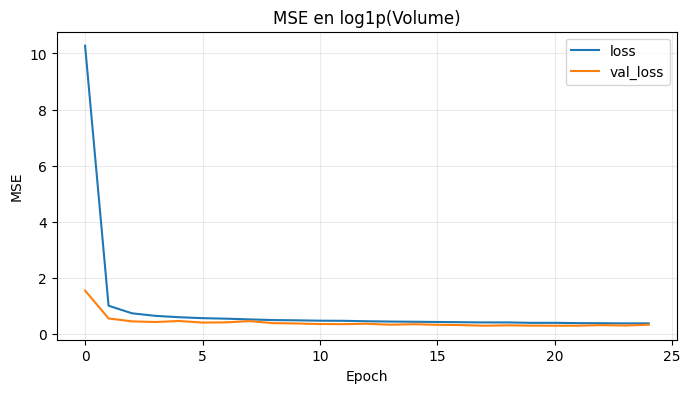

In [54]:
history_df = pd.DataFrame(history.history)
history_df[["loss", "val_loss"]].plot(figsize=(8, 4), title="MSE en log1p(Volume)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.grid(alpha=0.25)
plt.show()


## Pronóstico de una serie del conjunto test

In [116]:
seq_test = Xte[0][100]
ag_test = 33
sku_test = 11

In [117]:
model.predict([np.array([seq_test]), np.array([ag_test]), np.array([sku_test])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


array([[5.180731 , 5.1876082, 5.095686 ]], dtype=float32)

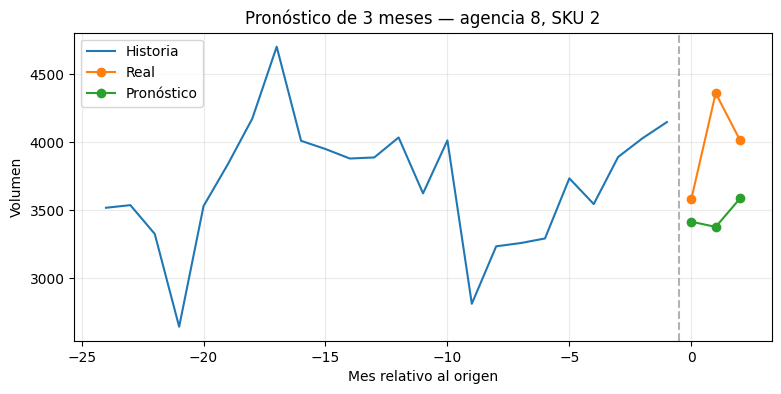

In [81]:
example = 55

agency = int(Xte[1][example])
sku = int(Xte[2][example])
origin = origin_month[test_idx][example]

# volume_log está escalado; se recupera solo esa columna mediante media/escala.
volume_log_idx = num_cols.index("volume_log")
past_log_scaled = Xte[0][example, :, volume_log_idx]
past_log = past_log_scaled * scaler.scale_[volume_log_idx] + scaler.mean_[volume_log_idx]
past_volume = np.expm1(past_log)

truth = Yte_volume[example]
forecast = Yhat_te[example]

plt.figure(figsize=(9, 4))
plt.plot(range(-LOOKBACK, 0), past_volume, label="Historia")
plt.plot(range(HORIZON), truth, marker="o", label="Real")
plt.plot(range(HORIZON), forecast, marker="o", label="Pronóstico")
plt.axvline(-0.5, color="black", alpha=0.3, linestyle="--")
plt.title(f"Pronóstico de {HORIZON} meses — agencia {agency}, SKU {sku}")
plt.xlabel("Mes relativo al origen")
plt.ylabel("Volumen")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [91]:
W_agency = model.layers[3].get_weights()
W_sku = model.layers[4].get_weights()

In [88]:
W_agency[0].shape

(58, 16)

In [93]:
W_sku[0].shape

(25, 16)

## Distribución de errores del test

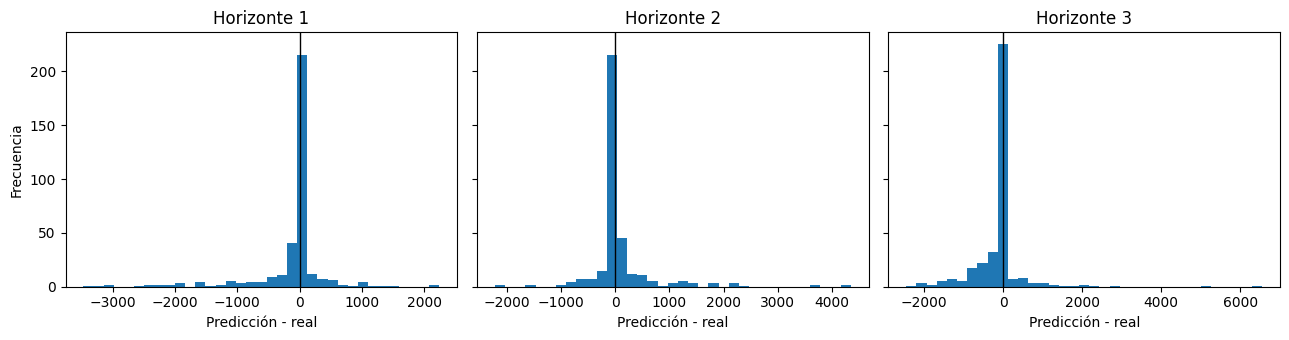

In [56]:
errors = Yhat_te - Yte_volume
fig, axes = plt.subplots(1, HORIZON, figsize=(13, 3.5), sharey=True)
for h, ax in enumerate(axes):
    ax.hist(errors[:, h], bins=35)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Horizonte {h + 1}")
    ax.set_xlabel("Predicción - real")
axes[0].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


-  Manejo de incertidumbre?
- ¿Las promociones futuras están planeadas o son observadas después?
- Experimentos interesantes
    - LSTM actual
    - LSTM + Huber
    - LSTM + calendario futuro
    - Ensamble
    - Holt-Winters